### 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob
from langdetect import detect, LangDetectException

### 2. Load Data

In [2]:

lyrics_df = pd.read_csv('Cleaned_lyrics_all.csv').dropna(subset=['lyrics'])
main_df = pd.read_csv('Spotify_weeklytop200_cleaned.csv')

print(f'Lyrics table: {len(lyrics_df)} songs')
print(f'Chart data  : {len(main_df)} rows  |  {main_df["id"].nunique()} unique songs')

Lyrics table: 7828 songs
Chart data  : 91709 rows  |  7820 unique songs


### 3. Language Detection and Filtering

In [3]:
def detect_lang(text):
    try:
        return detect(str(text)[:500])
    except LangDetectException:
        return 'unknown'

lyrics_df['language'] = lyrics_df['lyrics'].apply(detect_lang)

print('Language distribution (top 10):')
print(lyrics_df['language'].value_counts().head(10))

Language distribution (top 10):
language
en    5619
es    1200
pt     301
de     158
tr     108
it      87
ko      60
fr      56
ru      47
id      45
Name: count, dtype: int64


Total : 7828  |  Kept (en+es): 6819  |  Dropped: 1009


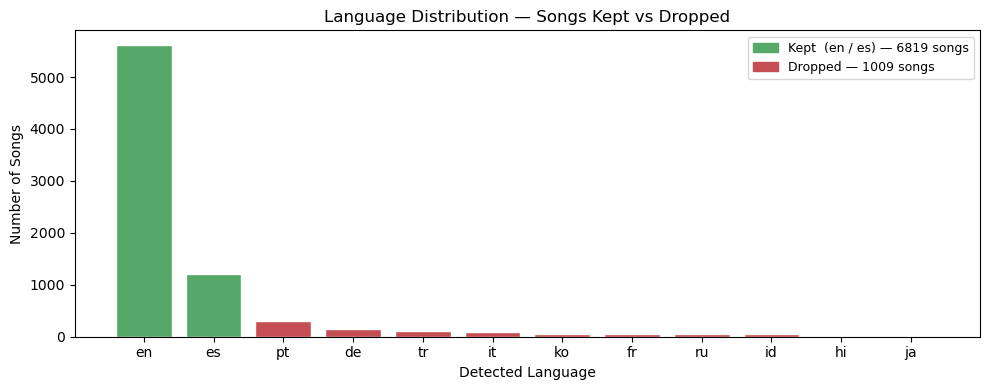

In [4]:
lang_counts = lyrics_df['language'].value_counts().head(12).reset_index()
lang_counts.columns = ['language', 'count']
lang_counts['kept'] = lang_counts['language'].isin(['en', 'es'])

total   = len(lyrics_df)
kept    = int(lang_counts[lang_counts['kept']]['count'].sum())
dropped = total - kept

print(f'Total : {total}  |  Kept (en+es): {kept}  |  Dropped: {dropped}')

bar_colors = ['#55A868' if k else '#C44E52' for k in lang_counts['kept']]
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lang_counts['language'], lang_counts['count'], color=bar_colors, edgecolor='white')
ax.set_xlabel('Detected Language')
ax.set_ylabel('Number of Songs')
ax.set_title('Language Distribution — Songs Kept vs Dropped')
ax.legend(handles=[
    mpatches.Patch(color='#55A868', label=f'Kept  (en / es) — {kept} songs'),
    mpatches.Patch(color='#C44E52', label=f'Dropped — {dropped} songs')
], fontsize=9)
plt.tight_layout()
plt.savefig('language_filter.png', dpi=150)
plt.show()

In [5]:
lyrics_en_es = lyrics_df[lyrics_df['language'].isin(['en', 'es'])].copy()
lyrics_en_es = lyrics_en_es[['id', 'Title', 'Artists_All', 'language', 'lyrics']].reset_index(drop=True)

print(f'After filtering: {len(lyrics_en_es)} songs')
print(lyrics_en_es['language'].value_counts())

After filtering: 6819 songs
language
en    5619
es    1200
Name: count, dtype: int64


### 4. Stage Lookup

In [6]:
stage_order  = ['Stage 1 (2017-2019)', 'Stage 2 (2020-2022)', 'Stage 3 (2023-2025)']
stage_labels = ['Pre-pandemic', 'Pandemic', 'Post-pandemic']
colors       = ['#4C72B0', '#DD8452', '#55A868']

def get_lyrics_for_stage(stage_name, language):
    stage_ids = main_df[main_df['Stage'] == stage_name]['id'].unique()
    result = lyrics_en_es[
        (lyrics_en_es['id'].isin(stage_ids)) &
        (lyrics_en_es['language'] == language)
    ].copy()
    return result

print('Songs retrieved per stage:')
for stage, label in zip(stage_order, stage_labels):
    n_en = len(get_lyrics_for_stage(stage, 'en'))
    n_es = len(get_lyrics_for_stage(stage, 'es'))
    print(f'  {label:18s}  en: {n_en:4d}   es: {n_es:4d}')

Songs retrieved per stage:
  Pre-pandemic        en: 2371   es:  308
  Pandemic            en: 2189   es:  468
  Post-pandemic       en: 1394   es:  441


### 5. Text Preprocessing

In [22]:
custom_stop = {
    'yeah', 'yeh', 'ooh', 'ah', 'oh', 'uh', 'wuh', 'na', 'la', 'hey', 'uah',
    'wan', 'wanna', 'gonna', 'gotta', 'feat',
    'chorus', 'verse', 'bridge', 'hook', 'intro', 'outro'
}

stop_en    = set(stopwords.words('english')) | custom_stop
stop_es    = set(stopwords.words('spanish')) | custom_stop
lemmatizer = WordNetLemmatizer()

def clean_lyrics(text):
    text = re.sub(r'\[.*?\]', ' ', str(text))
    text = re.sub(r"[^a-zA-ZáéíóúüñÁÉÍÓÚÜÑ']", ' ', text)
    return text.lower().strip()

def preprocess(text, lang):
    text   = clean_lyrics(text)
    tokens = word_tokenize(text)
    stop   = stop_es if lang == 'es' else stop_en
    tokens = [t for t in tokens if t.isalpha() and t not in stop and len(t) > 2]
    if lang == 'en':
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

### 6. TF-IDF — English Songs

In [23]:
TOP_N = 15
tfidf_en = {}

for stage, label in zip(stage_order, stage_labels):
    songs  = get_lyrics_for_stage(stage, 'en')
    corpus = songs['lyrics'].apply(lambda x: preprocess(x, 'en')).tolist()

    tfidf  = TfidfVectorizer(max_features=5000)
    X      = tfidf.fit_transform(corpus)
    scores = pd.Series(X.mean(axis=0).A1, index=tfidf.get_feature_names_out()).sort_values(ascending=False)

    tfidf_en[stage] = scores.head(TOP_N)
    print(f'{label}: {", ".join(scores.head(TOP_N).index.tolist())}')

Pre-pandemic: like, love, know, got, nigga, get, want, baby, let, one, time, never, bitch, say, back
Pandemic: like, love, know, got, get, nigga, baby, let, want, never, one, feel, time, say, need
Post-pandemic: like, know, love, got, baby, let, get, one, time, never, say, want, back, come, make


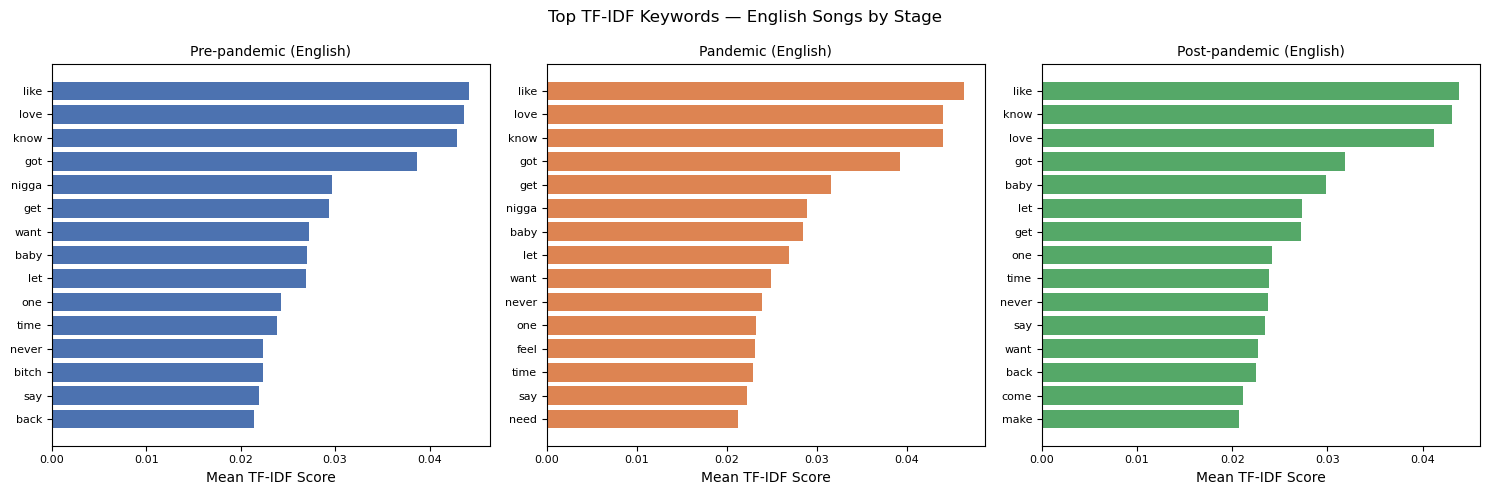

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, stage, label, color in zip(axes, stage_order, stage_labels, colors):
    words  = tfidf_en[stage].index[::-1]
    scores = tfidf_en[stage].values[::-1]
    ax.barh(words, scores, color=color)
    ax.set_title(f'{label} (English)', fontsize=10)
    ax.set_xlabel('Mean TF-IDF Score')
    ax.tick_params(labelsize=8)
plt.suptitle('Top TF-IDF Keywords — English Songs by Stage', fontsize=12)
plt.tight_layout()
plt.savefig('tfidf_english.png', dpi=150)
plt.show()

### 7. TF-IDF — Spanish Songs

In [25]:
tfidf_es = {}

for stage, label in zip(stage_order, stage_labels):
    songs  = get_lyrics_for_stage(stage, 'es')
    corpus = songs['lyrics'].apply(lambda x: preprocess(x, 'es')).tolist()

    tfidf  = TfidfVectorizer(max_features=5000)
    X      = tfidf.fit_transform(corpus)
    scores = pd.Series(X.mean(axis=0).A1, index=tfidf.get_feature_names_out()).sort_values(ascending=False)

    tfidf_es[stage] = scores.head(TOP_N)
    print(f'{label}: {", ".join(scores.head(TOP_N).index.tolist())}')

Pre-pandemic: quiero, baby, quiere, amor, bien, así, ahora, bebé, conmigo, baila, siempre, nadie, solo, dime, noche
Pandemic: quiero, baby, quiere, dime, siempre, noche, ahora, voy, bien, solo, cómo, ere, así, hace, contigo
Post-pandemic: bien, quiero, baby, solo, mami, siempre, amor, voy, bebé, noche, hoy, vez, aquí, así, cómo


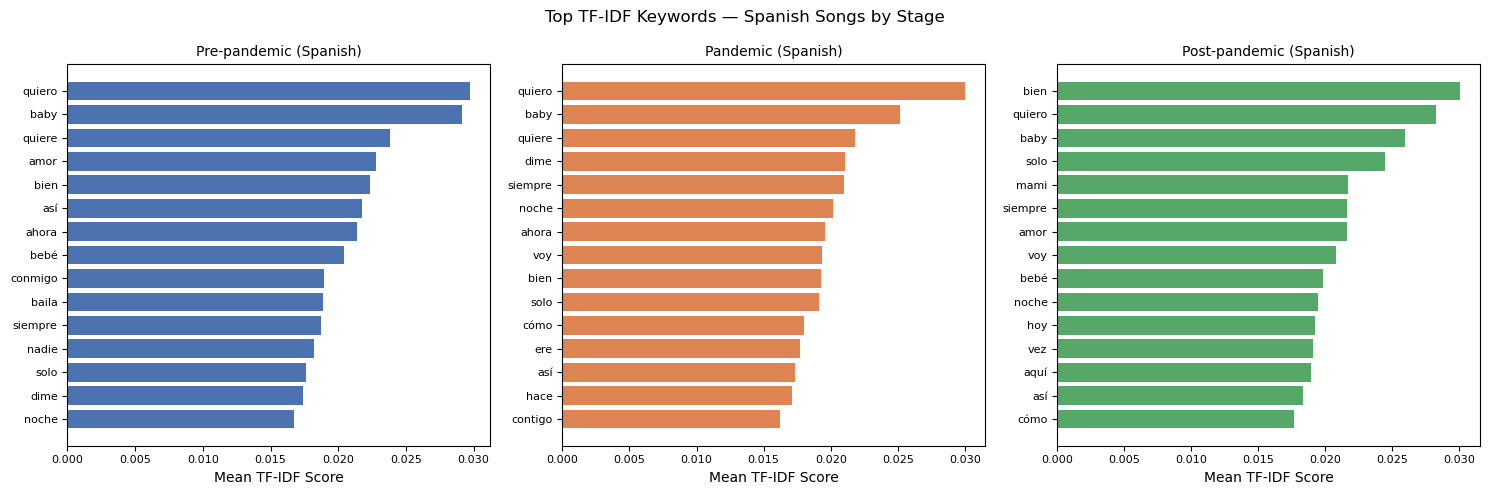

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, stage, label, color in zip(axes, stage_order, stage_labels, colors):
    words  = tfidf_es[stage].index[::-1]
    scores = tfidf_es[stage].values[::-1]
    ax.barh(words, scores, color=color)
    ax.set_title(f'{label} (Spanish)', fontsize=10)
    ax.set_xlabel('Mean TF-IDF Score')
    ax.tick_params(labelsize=8)
plt.suptitle('Top TF-IDF Keywords — Spanish Songs by Stage', fontsize=12)
plt.tight_layout()
plt.savefig('tfidf_spanish.png', dpi=150)
plt.show()

### 8. Sentiment Analysis — English Songs

In [27]:
sentiment_en = {}

for stage, label in zip(stage_order, stage_labels):
    songs = get_lyrics_for_stage(stage, 'en').copy()
    songs['polarity']     = songs['lyrics'].apply(lambda x: TextBlob(clean_lyrics(x)).sentiment.polarity)
    songs['subjectivity'] = songs['lyrics'].apply(lambda x: TextBlob(clean_lyrics(x)).sentiment.subjectivity)
    sentiment_en[label]   = songs

en_summary = pd.DataFrame({
    label: {
        'mean_polarity':     sentiment_en[label]['polarity'].mean(),
        'mean_subjectivity': sentiment_en[label]['subjectivity'].mean(),
        'n_songs':           len(sentiment_en[label])
    }
    for label in stage_labels
}).T.round(4)

print('English songs — sentiment summary:')
print(en_summary)

English songs — sentiment summary:
               mean_polarity  mean_subjectivity  n_songs
Pre-pandemic          0.0673             0.5121   2371.0
Pandemic              0.0771             0.5112   2189.0
Post-pandemic         0.0923             0.5085   1394.0


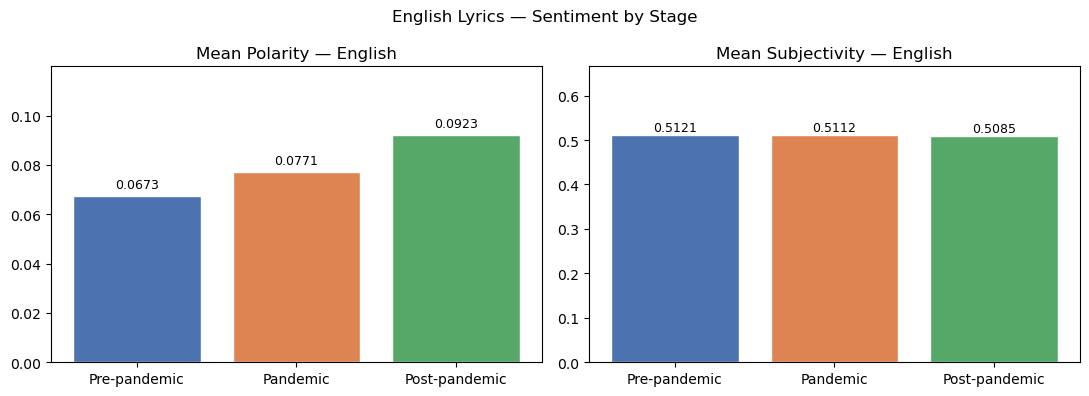

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col, title in zip(
    axes,
    ['mean_polarity', 'mean_subjectivity'],
    ['Mean Polarity — English', 'Mean Subjectivity — English']
):
    vals = en_summary[col].values
    bars = ax.bar(stage_labels, vals, color=colors, edgecolor='white')
    ax.set_title(title)
    ax.set_ylim(0, max(vals) * 1.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('English Lyrics — Sentiment by Stage', fontsize=12)
plt.tight_layout()
plt.savefig('sentiment_english_bar.png', dpi=150)
plt.show()

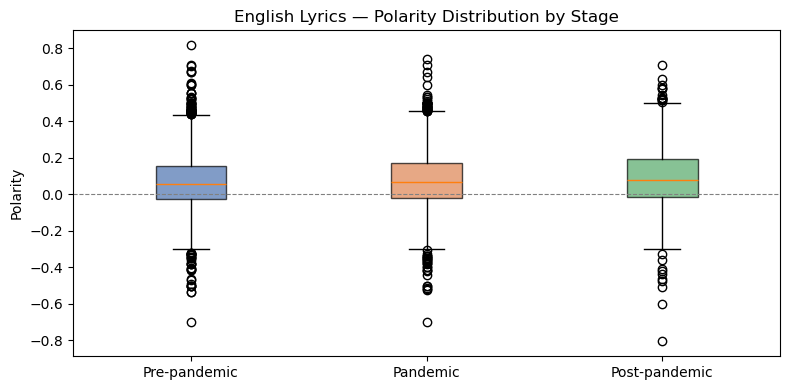

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))
data_to_plot = [sentiment_en[label]['polarity'].dropna().values for label in stage_labels]
bp = ax.boxplot(data_to_plot, labels=stage_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_ylabel('Polarity')
ax.set_title('English Lyrics — Polarity Distribution by Stage')
plt.tight_layout()
plt.savefig('polarity_english_box.png', dpi=150)
plt.show()

### 9. Sentiment Analysis — Spanish Songs

In [30]:
sentiment_es = {}

for stage, label in zip(stage_order, stage_labels):
    songs = get_lyrics_for_stage(stage, 'es').copy()
    songs['polarity']     = songs['lyrics'].apply(lambda x: TextBlob(clean_lyrics(x)).sentiment.polarity)
    songs['subjectivity'] = songs['lyrics'].apply(lambda x: TextBlob(clean_lyrics(x)).sentiment.subjectivity)
    sentiment_es[label]   = songs

es_summary = pd.DataFrame({
    label: {
        'mean_polarity':     sentiment_es[label]['polarity'].mean(),
        'mean_subjectivity': sentiment_es[label]['subjectivity'].mean(),
        'n_songs':           len(sentiment_es[label])
    }
    for label in stage_labels
}).T.round(4)

print('Spanish songs — sentiment summary:')
print(es_summary)

Spanish songs — sentiment summary:
               mean_polarity  mean_subjectivity  n_songs
Pre-pandemic          0.0371             0.3576    308.0
Pandemic              0.0142             0.3896    468.0
Post-pandemic         0.0113             0.3146    441.0


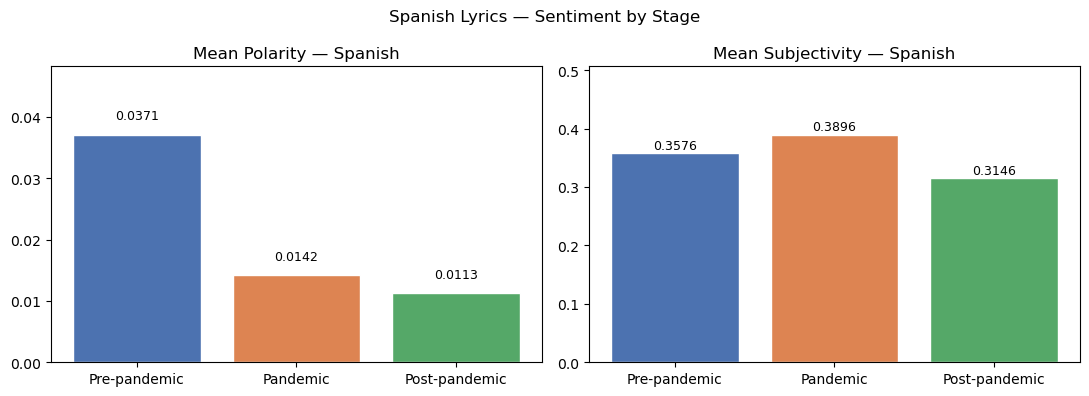

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col, title in zip(
    axes,
    ['mean_polarity', 'mean_subjectivity'],
    ['Mean Polarity — Spanish', 'Mean Subjectivity — Spanish']
):
    vals = es_summary[col].values
    bars = ax.bar(stage_labels, vals, color=colors, edgecolor='white')
    ax.set_title(title)
    ax.set_ylim(0, max(vals) * 1.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Spanish Lyrics — Sentiment by Stage', fontsize=12)
plt.tight_layout()
plt.savefig('sentiment_spanish_bar.png', dpi=150)
plt.show()

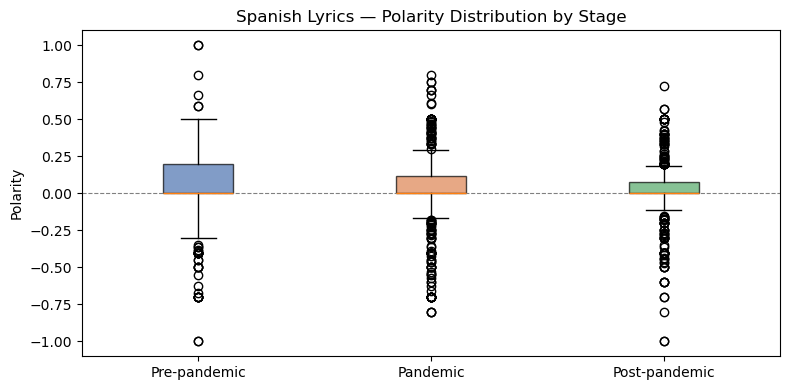

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))
data_to_plot = [sentiment_es[label]['polarity'].dropna().values for label in stage_labels]
bp = ax.boxplot(data_to_plot, labels=stage_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_ylabel('Polarity')
ax.set_title('Spanish Lyrics — Polarity Distribution by Stage')
plt.tight_layout()
plt.savefig('polarity_spanish_box.png', dpi=150)
plt.show()

### 10. Summary and Export

In [33]:
print('=== English Sentiment ===')
print(en_summary)
print()
print('=== Spanish Sentiment ===')
print(es_summary)

=== English Sentiment ===
               mean_polarity  mean_subjectivity  n_songs
Pre-pandemic          0.0673             0.5121   2371.0
Pandemic              0.0771             0.5112   2189.0
Post-pandemic         0.0923             0.5085   1394.0

=== Spanish Sentiment ===
               mean_polarity  mean_subjectivity  n_songs
Pre-pandemic          0.0371             0.3576    308.0
Pandemic              0.0142             0.3896    468.0
Post-pandemic         0.0113             0.3146    441.0


In [34]:
rows = []
for label in stage_labels:
    for lang, d in [('en', sentiment_en), ('es', sentiment_es)]:
        tmp = d[label][['id', 'Title', 'Artists_All', 'language', 'polarity', 'subjectivity']].copy()
        tmp['Stage_Label'] = label
        rows.append(tmp)

df_sentiment = pd.concat(rows, ignore_index=True)
df_sentiment.to_csv('df_sentiment.csv', index=False)
print(f'Saved df_sentiment.csv — {len(df_sentiment)} rows')
print(df_sentiment.groupby(['Stage_Label', 'language']).size())

Saved df_sentiment.csv — 7171 rows
Stage_Label    language
Pandemic       en          2189
               es           468
Post-pandemic  en          1394
               es           441
Pre-pandemic   en          2371
               es           308
dtype: int64
